<a href="https://colab.research.google.com/github/NiroNithy/Personal_Portfolio/blob/Research/People_CatBoost__KFoldipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
#LOAD THE DATA
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

df=pd.read_csv('//content/PeopleBank Dataset.csv',encoding='ISO-8859-1')
df

,content,at,appVersion
0,"After the recent update, I can't use the app. ...",2025-01-25T06:58:49,V 1.36.1.2
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2
3,I updated this app on 25 th January 2025. Afte...,2025-01-25T01:09:05,V 1.36.1.2
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2
...,...,...,...
915,Super,2022-01-18T06:42:34,V 1.24.1.2
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2
918,"Transaction confirmation pdf not received. So,...",2022-01-11T07:04:08,V 1.24.1.2


In [ ]:
# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Preprocessing function
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    return ' '.join(word for word in words if word.isalnum() and word not in stop_words)

In [ ]:
# Apply preprocessing to the content column
df['cleaned_content'] = df['content'].apply(preprocess_text)

In [ ]:
df

,content,at,appVersion,cleaned_content
0,"After the recent update, I can't use the app. ...",2025-01-25T06:58:49,V 1.36.1.2,recent update ca use app keep showing device a...
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...
3,I updated this app on 25 th January 2025. Afte...,2025-01-25T01:09:05,V 1.36.1.2,updated app 25 th january open app message app...
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server
...,...,...,...,...
915,Super,2022-01-18T06:42:34,V 1.24.1.2,super
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication
918,"Transaction confirmation pdf not received. So,...",2022-01-11T07:04:08,V 1.24.1.2,transaction confirmation pdf received prove so...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Initialize VADER Sentiment Analyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
#Take Sentiment Score
def classify_sentiment(score):
  if score >= 0.05:
    return 'positive'
  elif score <= 0.05:
    return 'negative'
  else:
    return 'netural'

#new output column as sentiment score(value)
df['sentiment_score'] = df['content'].apply(lambda x:sia.polarity_scores(x)['compound'])
df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)

In [ ]:
df

,content,at,appVersion,cleaned_content,sentiment_score,sentiment
0,"After the recent update, I can't use the app. ...",2025-01-25T06:58:49,V 1.36.1.2,recent update ca use app keep showing device a...,0.3182,positive
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...,0.0000,negative
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...,0.0000,negative
3,I updated this app on 25 th January 2025. Afte...,2025-01-25T01:09:05,V 1.36.1.2,updated app 25 th january open app message app...,0.3182,positive
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server,0.0000,negative
...,...,...,...,...,...,...
915,Super,2022-01-18T06:42:34,V 1.24.1.2,super,0.5994,positive
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem,-0.4019,negative
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication,0.0000,negative
918,"Transaction confirmation pdf not received. So,...",2022-01-11T07:04:08,V 1.24.1.2,transaction confirmation pdf received prove so...,0.0000,negative


In [ ]:
#Filter rows with negative sentiment
negative_reviews = df[df['sentiment'] == 'negative']

In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...,0.0000,negative
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...,0.0000,negative
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server,0.0000,negative
6,Always app is not working.It says server timeout,2025-01-21T05:26:13,V 1.34.1.2,always app says server timeout,0.0000,negative
8,"Sometimes when using it, its functionality doe...",2025-01-13T08:15:39,V 1.34.1.2,sometimes using functionality seem work unable...,0.0000,negative
...,...,...,...,...,...,...
911,"After we transfer to money to other account,ca...",2022-01-25T08:25:56,V 1.24.1.2,transfer money account ca download responsible,-0.2411,negative
912,I am using my mobile phone to connect. But eve...,2022-01-24T03:14:41,V 1.24.1.2,using mobile phone connect everytime trying lo...,0.0000,negative
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem,-0.4019,negative
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication,0.0000,negative


In [ ]:
# Convert text to a TF-IDF representation
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf_dtm = tfidf_vectorizer.fit_transform(negative_reviews['cleaned_content'])

In [ ]:
# Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=2, random_state=42)  # Assume 2 topics (UI, UX)
lda.fit(tfidf_dtm)

LatentDirichletAllocation(n_components=2, random_state=42)

In [ ]:
# Extract keywords for each topic
def get_top_keywords(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[f"Topic {topic_idx + 1}"] = [feature_names[i] for i in topic.argsort()[-n_top_words:]]
    return topics

n_top_words = 20
feature_names = tfidf_vectorizer.get_feature_names_out()
topics = get_top_keywords(lda, feature_names, n_top_words)

In [ ]:
print("Identified Topics with Keywords:")
for topic, keywords in topics.items():
   print(f"{topic}: {', '.join(keywords)}")

Identified Topics with Keywords:
Topic 1: useless, need, screenshot, transaction, poor, banking, change, open, friendly, service, login, slow, bank, user, ca, time, password, bad, worst, app
Topic 2: error, screen, wasting, payment, people, naic, time, mobile, usefull, properly, account, work, app, new, log, connect, server, unable, update, working


In [ ]:
#Assign the most probable topic to each review
negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)

<ipython-input-20-1c6ee9867e2a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)


In [ ]:
# Map topic numbers to labels
topic_labels = {0: 'UI', 1: 'UX'}
negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)

<ipython-input-21-6f27e2f65528>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)


In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment,topic,classification
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...,0.0000,negative,1,UX
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...,0.0000,negative,1,UX
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server,0.0000,negative,1,UX
6,Always app is not working.It says server timeout,2025-01-21T05:26:13,V 1.34.1.2,always app says server timeout,0.0000,negative,0,UI
8,"Sometimes when using it, its functionality doe...",2025-01-13T08:15:39,V 1.34.1.2,sometimes using functionality seem work unable...,0.0000,negative,1,UX
...,...,...,...,...,...,...,...,...
911,"After we transfer to money to other account,ca...",2022-01-25T08:25:56,V 1.24.1.2,transfer money account ca download responsible,-0.2411,negative,0,UI
912,I am using my mobile phone to connect. But eve...,2022-01-24T03:14:41,V 1.24.1.2,using mobile phone connect everytime trying lo...,0.0000,negative,1,UX
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem,-0.4019,negative,0,UI
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication,0.0000,negative,1,UX


In [ ]:
# Split the data into training and testing sets
X = tfidf_dtm.toarray()
Y = negative_reviews['classification'].apply(lambda x: 0 if x == 'UI' else 1)

In [ ]:
# K-Fold Cross-Validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
mse_values = []

In [ ]:
# Ensure X and Y are NumPy arrays
X = np.array(X)  # Convert X to a NumPy array if it isn't already
Y = np.array(Y)  # Convert Y to a NumPy array if it isn't already

In [ ]:
!pip install numpy==1.23.5
!pip install catboost==1.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 8.1 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

In [ ]:
# Initialize CatBoost
catboost = CatBoostClassifier(verbose=0, random_state=42)

In [ ]:
for train_index, test_index in kf.split(X, Y):
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]

    catboost.fit(X_train, Y_train)
    Y_pred = catboost.predict(X_test)
    fold_accuracies.append(accuracy_score(Y_test, Y_pred))
    mse_values.append(mean_squared_error(Y_test, Y_pred))


In [ ]:
print(f"CatBoost Fold Accuracies: {fold_accuracies}")
print(f"CatBoost Mean Accuracy: {sum(fold_accuracies)/len(fold_accuracies):.2f}")

CatBoost Fold Accuracies: [0.8888888888888888, 0.8555555555555555, 0.7777777777777778, 0.8222222222222222, 0.8444444444444444]
CatBoost Mean Accuracy: 0.84


In [ ]:
print(f"CatBoost Fold MSE Values: {mse_values}")
print(f"CatBoost Mean MSE: {sum(mse_values) / len(mse_values):.2f}")

CatBoost Fold MSE Values: [0.1111111111111111, 0.14444444444444443, 0.2222222222222222, 0.17777777777777778, 0.15555555555555556]
CatBoost Mean MSE: 0.16


In [ ]:
# Detailed Classification Report
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred, target_names=['UI', 'UX']))
# Or individual scores
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Classification Report:
              precision    recall  f1-score   support

          UI       0.86      0.94      0.89        63
          UX       0.81      0.63      0.71        27

    accuracy                           0.84        90
   macro avg       0.83      0.78      0.80        90
weighted avg       0.84      0.84      0.84        90

Precision: 0.81
Recall: 0.63
F1 Score: 0.71


In [ ]:
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(Y_test, Y_pred)
print(conf_matrix)


Confusion Matrix:
[[59  4]
 [10 17]]


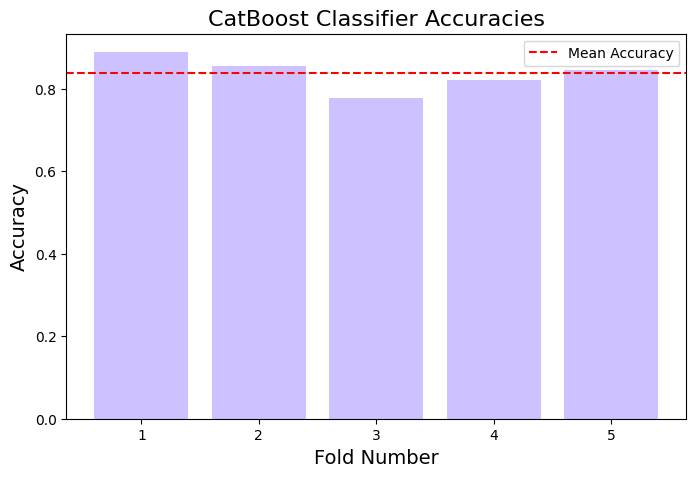

In [ ]:
# Plot the accuracies
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(fold_accuracies) + 1), fold_accuracies, color='#CDC1FF')
plt.axhline(y=np.mean(fold_accuracies), color='r', linestyle='--', label='Mean Accuracy')
plt.title('CatBoost Classifier Accuracies', fontsize=16)
plt.xlabel('Fold Number', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(range(1, len(fold_accuracies) + 1))
plt.legend()
plt.show()